
piecewise-looking graph:
h=0.10000, dt=0.000042, r=0.0042
10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 
c = 1.791648

compact-like initial:
h=0.05000, dt=0.000031, r=0.0125
10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 
c = 1.243511

piece-wise looking graph: c = 1.791648
compact-like initial: c = 1.243511


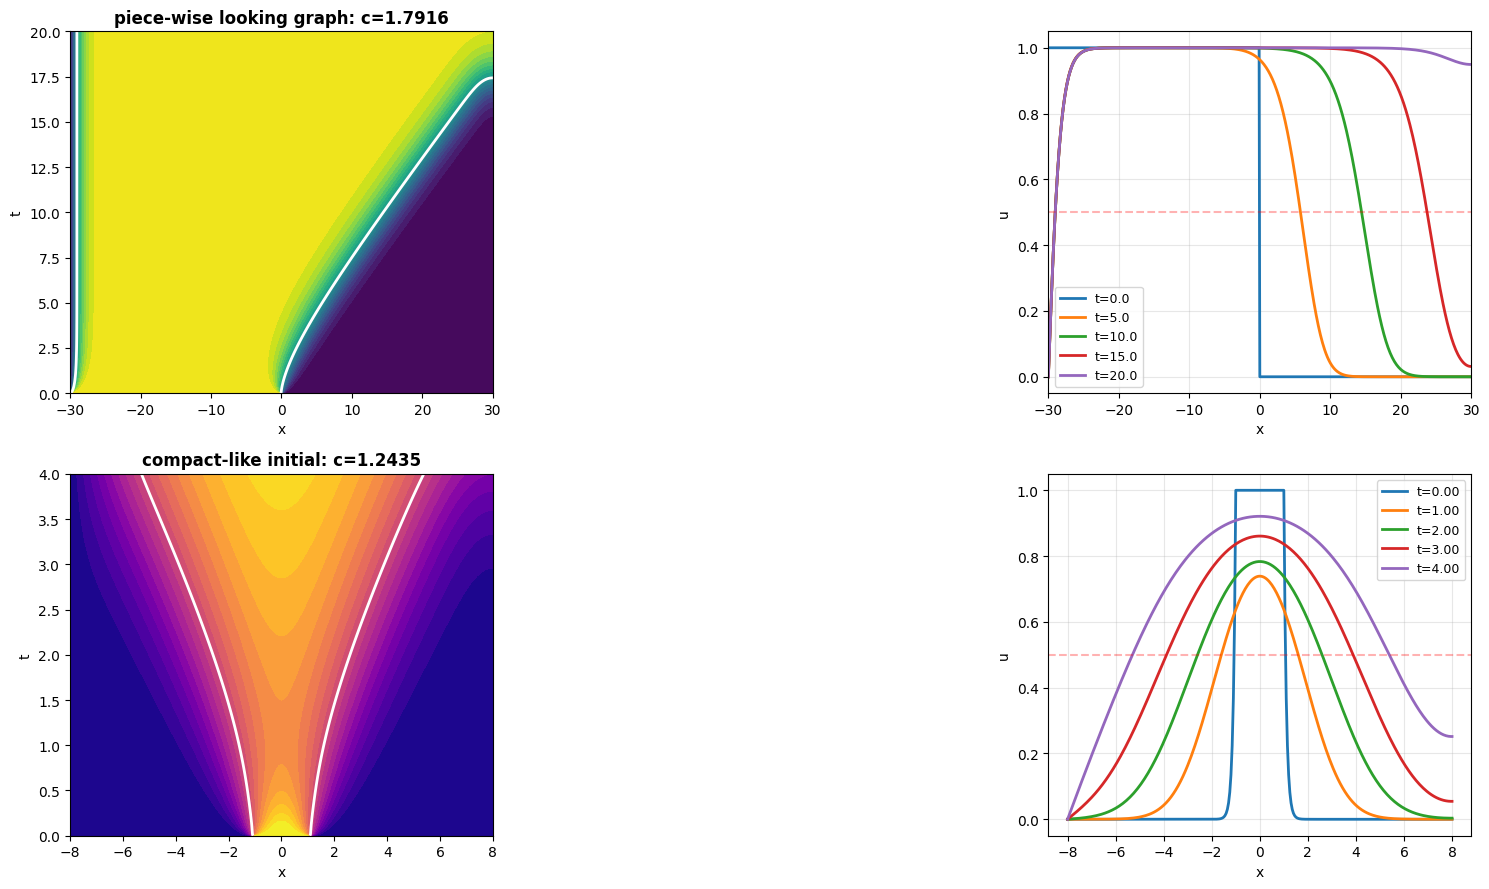

In [10]:
# Fisher-KPP Wave Speed
# du/dt = d2u/dx2 + u(1-u)

import numpy as np
import matplotlib.pyplot as plt

def solve(x0, x1, T, N, M, ic):
    h = (x1 - x0) / (N - 1)
    dt = T / M
    r = dt / h**2

    print(f"h={h:.5f}, dt={dt:.6f}, r={r:.4f}")

    x = np.linspace(x0, x1, N)
    t = np.linspace(0, T, M+1)
    u = np.zeros((M+1, N))
    u[0, :] = ic(x)

    # time loop
    for n in range(M):
        u[n+1, 0] = u[n+1, 1] if n > 0 else u[n, 0]

        for i in range(1, N-1):
            u[n+1, i] = u[n,i] + r*(u[n,i+1]-2*u[n,i]+u[n,i-1]) + dt*u[n,i]*(1-u[n,i])

        u[n+1, N-1] = u[n+1, N-2]

        if (n+1) % (M//10) == 0:
            print(f"{100*(n+1)//M}%", end=" ")
    print()

    return x, t, u

# get speed
def speed(x, t, u):
    pos, times = [], []

    for n in range(len(t)//5, len(t)):
        idx = np.where((x > 0) & (u[n,:] > 0.5))[0]
        if len(idx) > 0:
            pos.append(x[idx[-1]])
            times.append(t[n])

    c = np.polyfit(times, pos, 1)[0]
    print(f"c = {c:.6f}")

    return c, np.array(times), np.array(pos)

# initial conditions
ic1 = lambda x: np.where(x < 0, 1.0, 0.0)

def ic2(x):
    u = np.zeros_like(x)
    u[x < -1] = np.exp(10*(x[x<-1]+1))
    u[(x>=-1) & (x<=1)] = 1.0
    u[x > 1] = np.exp(-10*(x[x>1]-1))
    return u

# piecewise-looking graph
print("\npiecewise-looking graph:")
x1, t1, u1 = solve(-30, 30, 20, 601, 480000, ic1)
c1, tc1, xc1 = speed(x1, t1, u1)

# compact-like initial
print("\ncompact-like initial:")
x2, t2, u2 = solve(-8, 8, 4, 321, 128000, ic2)
c2, tc2, xc2 = speed(x2, t2, u2)

# plots
fig = plt.figure(figsize=(15, 9))

M1, M2 = len(t1)-1, len(t2)-1

# piecewise-looking graph
ax = plt.subplot(2,3,1)
ax.contourf(x1, t1[::1200], u1[::1200,:], 20, cmap='viridis')
ax.contour(x1, t1[::1200], u1[::1200,:], [0.5], colors='w', linewidths=2)
ax.set_title(f'piece-wise looking graph: c={c1:.4f}', fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('t')


ax = plt.subplot(2,3,3)
for i in [0, M1//4, M1//2, 3*M1//4, M1]:
    ax.plot(x1, u1[i,:], lw=2, label=f't={t1[i]:.1f}')
ax.axhline(0.5, color='r', ls='--', alpha=0.3)
ax.set_xlabel('x'); ax.set_ylabel('u')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlim(-30, 30)

# compact-like initial
ax = plt.subplot(2,3,4)
ax.contourf(x2, t2[::320], u2[::320,:], 20, cmap='plasma')
ax.contour(x2, t2[::320], u2[::320,:], [0.5], colors='w', linewidths=2)
ax.set_title(f'compact-like initial: c={c2:.4f}', fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('t')

ax = plt.subplot(2,3,6)
for i in [0, M2//4, M2//2, 3*M2//4, M2]:
    ax.plot(x2, u2[i,:], lw=2, label=f't={t2[i]:.2f}')
ax.axhline(0.5, color='r', ls='--', alpha=0.3)
ax.set_xlabel('x'); ax.set_ylabel('u')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('wave_speed.png', dpi=150)
print(f"\npiece-wise looking graph: c = {c1:.6f}")
print(f"compact-like initial: c = {c2:.6f}")
plt.show()
